#  HI fluxes

Here we aim to explore the HI fluxes from different catalogs using [edge_pydb](https://github.com/tonywong94/edge_pydb)

1. edge_leda (647 entries, but only 453 have fluxes)
2. edge_hiflux (161 entries; edge2015 and some more)
3. CALIFA_HI_sample_archive.csv (923 entries)
4. hiedge_all.csv (568 entries)


5. FASHI (41741 entries)
6. ALFALFA  (31502 entries) = a100

Also of use

1. iEDGE (643 entries) 
2. edge_califa (671 entries)
3. amusing (621 entries)

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy.table import Table, join
from astropy import units as u
from edge_pydb import EdgeTable


In [1]:
def common(t1, t2, c1, c2):
    print(len(t1),len(t2))
    t2c = t2[c2]
    mask = np.isin(t1[c1], t2c)
    return t1[mask]

In [ ]:
EdgeTable('list')

In [ ]:
# there's a "bug" in edge_pydb in that it doesn't recognize ecsv yet. I have a PR coming
if True:
    from edge_pydb import util
    util.updatefiles()
    EdgeTable('list')

In [ ]:
# note the comment line became a row
amusing = EdgeTable('amusing_sample_char.csv')
amusing.keys()

In [ ]:
#leda = pd.read_csv('edge_leda.csv')
#leda = np.loadtxt('edge_leda.csv', skiprows=1, delimiter=',')
#leda = np.genfromtxt('edge_leda.csv', skip_header=1, delimiter=',')
leda = EdgeTable('edge_leda.csv')

In [ ]:
leda.info()


In [ ]:
# Name,ledaHIflux
idx = ~leda['ledaHIflux'].mask

# 453 galaxies (out of 647) have a flux
leda_haveflux = leda['Name'][idx]
leda_flux = leda['ledaHIflux'][idx]
#leda_flux


In [ ]:
iedge = EdgeTable("iedge_v1.csv")

In [ ]:
iedge.info()

In [ ]:
edge_hiflux = EdgeTable("edge_hiflux.csv")


In [ ]:
edge_hiflux
# Name, SigInt, SigUnc
edge_hiflux['Name']


In [ ]:
califa = EdgeTable('edge_califa.csv')


In [ ]:
califa

## LEDA vs. EDGE

Take all edge_leda galaxies which have a known flux (no error bars available). Then find the flux in edge_hiflux for those galaxies

In [ ]:
#leda = EdgeTable('edge_leda.csv', cols=['Name', 'ledaHIflux'])
leda = EdgeTable('edge_leda.csv')

In [ ]:
edge_hiflux = EdgeTable("edge_hiflux.csv", cols=['Name', 'SigInt', 'SigUnc'])

In [ ]:
leda.join(edge_hiflux)
len(leda)

In [ ]:
leda.keys()
print(leda)

In [ ]:
fig, ax = plt.subplots()
ax.plot(leda['ledaHIflux'], leda['SigInt'], 'o')
ax.errorbar(leda['ledaHIflux'], leda['SigInt'], yerr=leda['SigUnc'],ls='none')
fmin = 0
fmax = 20
ax.set_xlim(fmin,fmax)
ax.set_ylim(fmin,fmax)
ax.grid()
ax.set_aspect('equal')
ax.plot([fmin,fmin],[fmax,fmax],'-', color='red')
ax.set_xlabel("LEDA flux")
ax.set_ylabel("EDGE_HIFLUX")

# Cross matching catalogs

```   
 t1   edge_leda.csv                    647
 t2   iedge_v1.ecsv                    643
 t3   edge_hiflux.csv                  159   only has names, no ra,dec
 t4   edge2025.csv                      43   only has names, no ra,dec
 t5   CALIFA_HI_sample_archive.csv     923   562 have flux, 361 have no archived flux
 t6   hiedge_all.csv                   568   only names, from veselina's spectra plots
 a100 a100.code12.table2.190808.csv  31502

In [2]:
from astropy import units as u
from astropy.coordinates import SkyCoord, Distance
from astropy.table import QTable
from astropy.table import Table, join
from astropy.time import Time


In [3]:
t1 = QTable.read("edge_leda.csv", format="ecsv")
t1.keys()[:7]

['Name', 'ledaName', 'ledaRA', 'ledaDE', 'ledaMorph', 'ledaBar', 'ledaRing']

In [4]:
t1c = SkyCoord(t1["ledaRA"], t1["ledaDE"])

In [5]:
t2 = QTable.read("iedge_v1.ecsv", format="ecsv")
t2.keys()[:7]

['CALIFA_name', 'Alias', 'RA', 'DEC', 'Vlsr', 'zstar', 'Distance']

In [6]:
t2c = SkyCoord(t2["RA"], t2["DEC"])

Check overlap between t1 and t2 based on their coordinates.   it is surprising that this is not close,
limiting to 10" there are only 478/643.... odd.

In [7]:
idx, sep, _ = t1c.match_to_catalog_sky(t2c)

(sep < 10 * u.arcsec).sum(), len(t2)

(np.int64(478), 643)

Text(0.5, 1.0, 'leda and iedge')

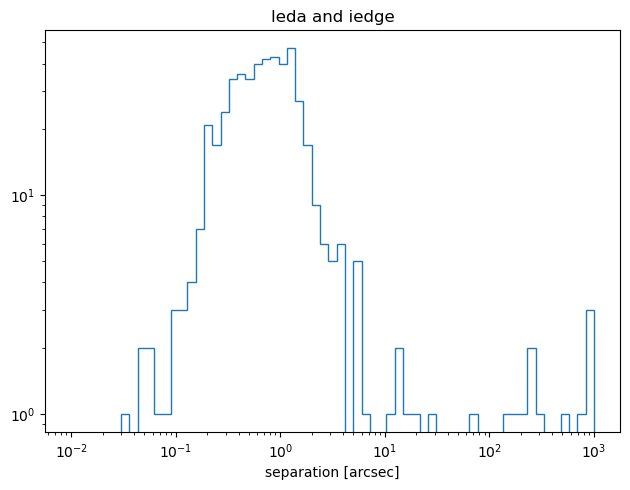

In [8]:
plt.hist(sep.arcsec, histtype="step", bins=np.logspace(-2, 3, 64))
plt.xlabel("separation [arcsec]")
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.title('leda and iedge')

In [9]:
t3 = QTable.read("edge_hiflux.csv", format="ecsv")
t3n = t3["Name"]

In [10]:
t31 = join(t3,t1)
len(t31)
#t31.keys()

159

Text(0.5, 1.0, 'GBT + LEDA: 159 entries')

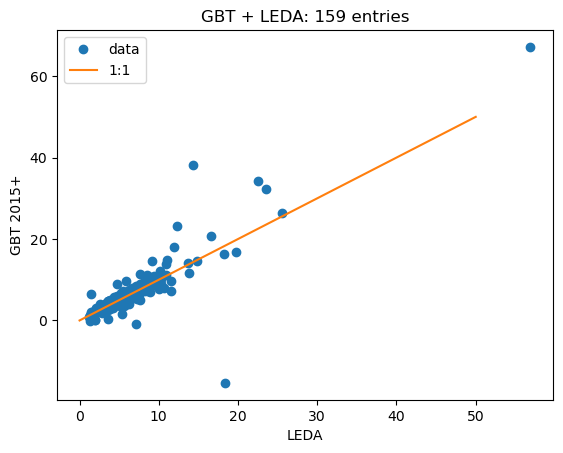

In [11]:
flux1 = t31["ledaHIflux"]
flux3 = t31["SigInt"]


plt.plot(flux1,flux3,'o',label="data")
plt.plot([0,50], [0,50], '-', label="1:1")
plt.xlabel("LEDA")
plt.ylabel("GBT 2015+")
#plt.aspect("equal")
plt.legend();
plt.title(f"GBT + LEDA: {len(t31)} entries")

In [12]:
t4 = Table.read("edge2025.csv", format="ecsv")
t4n = t4["Name"]

In [13]:
t41 = join(t4,t1)
len(t41)

43

Text(0.5, 1.0, 'GBT25 + LEDA: 43 entries')

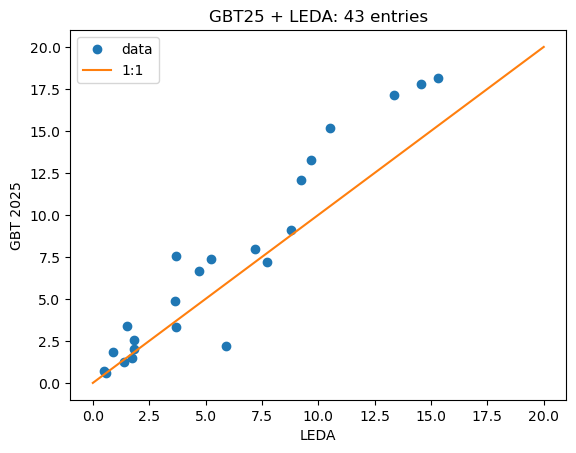

In [14]:
flux1 = t41["ledaHIflux"]
flux4 = t41["SigInt"]

plt.plot(flux1,flux4,'o',label="data")
plt.plot([0,20], [0,20], '-', label="1:1")
plt.xlabel("LEDA")
plt.ylabel("GBT 2025")
plt.legend();
plt.title(f"GBT25 + LEDA: {len(t41)} entries")

In [15]:
t41.keys()

['Name',
 'Refcode',
 'Vsys',
 'Deltav',
 'Robust_rms',
 'RefInt',
 'RefUnc',
 'SigInt',
 'SigUnc',
 'SigVmin',
 'SigVmax',
 'BadFlag',
 'ledaName',
 'ledaRA',
 'ledaDE',
 'ledaMorph',
 'ledaBar',
 'ledaRing',
 'ledaMultiple',
 'ledaType',
 'ledaPA',
 'ledaBt',
 'ledaIt',
 'ledaVmaxg',
 'ledaFIR',
 'ledaVrad',
 'ledaA_Bgal',
 'ledaIncl',
 'ledaVrot',
 'ledaVvir',
 'ledaModz',
 'ledaD25',
 'ledaAxrat',
 'ledaAxIncl',
 'ledaDistMpc',
 'ledaHIflux',
 'ID']

In [16]:
# panda's style doesn't work for tables
#  t2[t2["CALIFA_name"].isin(t3n)]

# would need to convert to pandas:
# pt2 = t2.to_pandas()


In [17]:
# Create mask and extract rows
mask = np.isin(t2['CALIFA_name'], t3n)
t2_3 = t2[mask]
len(t2),len(t2_3)

(643, 161)

In [18]:
t1.keys()
t41 = common(t1,t4,"ledaName","Name")
t41

647 43


Name,ledaName,ledaRA,ledaDE,ledaMorph,ledaBar,ledaRing,ledaMultiple,ledaType,ledaPA,ledaBt,ledaIt,ledaVmaxg,ledaFIR,ledaVrad,ledaA_Bgal,ledaIncl,ledaVrot,ledaVvir,ledaModz,ledaD25,ledaAxrat,ledaAxIncl,ledaDistMpc,ledaHIflux,ID
,,deg,deg,,,,,,deg,mag,mag,km / s,mag,km / s,mag,deg,km / s,km / s,mag,arcmin,,deg,Mpc,Jy km / s,
str23,str23,float64,float64,str4,str1,str1,str1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
IC0674,IC0674,167.776497,43.633019,Sab,B,R,--,2.0,121.03,14.356,12.945,241.85,———,7507.0,0.064,85.27,242.68,7691.6,35.252,1.37,0.3020,76.9,112.31,3.70,381
IC2341,IC2341,125.922615,21.4348704,E-S0,--,--,--,-3.1,2.58,14.639,12.432,———,———,5132.6,0.212,90.0,———,5133.3,34.37,1.18,0.4842,68.9,74.82,———,197
IC4215,IC4215,199.070475,25.405678,Sab,--,--,--,2.0,45.51,14.627,13.246,158.87,13.842,3883.6,0.071,90.0,158.87,4068.2,33.866,1.55,0.2344,83.2,59.32,0.51,615
MCG-01-01-012,MCG-01-01-012,359.795061,-4.1919115,Sb,--,--,--,3.2,70.0,15.05,12.62,171.6,———,5764.6,0.159,90.0,171.6,5719.1,34.601,1.57,0.2173,82.9,83.21,1.50,936
MCG-01-52-012,MCG-01-52-012,309.4582725,-6.0907463,E,--,--,--,-4.0,72.73,14.659,12.895,———,———,3859.0,0.265,60.02,———,3929.3,33.778,1.16,0.7244,48.2,56.96,———,3039
NGC0681,NGC0681,27.2951475,-10.4265532,SABa,B,R,--,2.0,66.75,12.769,11.476,172.17,11.831,1748.1,0.149,46.28,238.21,1607.5,31.863,2.51,0.7228,44.9,23.58,14.53,61
NGC0787,NGC0787,30.2024025,-9.0027307,Sb,--,R,--,3.0,91.23,13.627,11.797,162.24,———,4746.9,0.123,48.21,217.59,4606.7,34.132,1.87,0.6934,47.1,67.05,———,75
NGC0991,NGC0991,38.886213,-7.1544011,SABc,B,R,M,5.2,152.0,12.96,12.051,33.62,13.122,1531.8,0.12,28.1,71.37,1383.4,31.518,1.48,0.8872,27.8,20.12,15.32,95


In [19]:
a=common(t2,t3,"CALIFA_name","Name")
b=common(t3,t2,"Name","CALIFA_name")

643 161
161 643


In [20]:
a

CALIFA_name,Alias,RA,DEC,Vlsr,zstar,Distance,Incl,PA,Re_as,Glob_med_EWHa,Glob_Mstar,Glob_SFR,Glob_sSFR,Err_Glob_Mstar,Err_Glob_SFR,Err_Glob_sSFR,Glob_Gas_Met,Glob_alpha_co10_b13,Glob_R21,APEX_Glob_k2jypb,APEX_Glob_eta_mb,APEX_Glob_RMS,APEX_Glob_Tpeak,APEX_Glob_SNR,APEX_Glob_W50_mom2,APEX_Glob_eps_obs,APEX_Glob_Fco,APEX_Glob_Lco,APEX_Glob_Mmol,APEX_Glob_fmol,APEX_Glob_SFE,CARMA_Glob_k2jypb,CARMA_Glob_eta_mb,CARMA_Glob_RMS,CARMA_Glob_Tpeak,CARMA_Glob_SNR,CARMA_Glob_W50_mom2,CARMA_Glob_eps_obs,CARMA_Glob_Fco,CARMA_Glob_Lco,CARMA_Glob_Mmol,CARMA_Glob_fmol,CARMA_Glob_SFE,ACA_Glob_k2jypb,ACA_Glob_eta_mb,ACA_Glob_RMS,ACA_Glob_Tpeak,ACA_Glob_SNR,ACA_Glob_W50_mom2,ACA_Glob_eps_obs,ACA_Glob_Fco,ACA_Glob_Lco,ACA_Glob_Mmol,ACA_Glob_fmol,ACA_Glob_SFE,Final_Glob_Observatory,Final_Glob_SNR,Final_Glob_Mmol,Final_Glob_fmol,Final_Glob_SFE,APEX_Err_Glob_Fco,APEX_Err_Glob_Lco,APEX_Err_Glob_Mmol,APEX_Err_Glob_fmol,APEX_Err_Glob_SFE,CARMA_Err_Glob_Fco,CARMA_Err_Glob_Lco,CARMA_Err_Glob_Mmol,CARMA_Err_Glob_fmol,CARMA_Err_Glob_SFE,ACA_Err_Glob_Fco,ACA_Err_Glob_Lco,ACA_Err_Glob_Mmol,ACA_Err_Glob_fmol,ACA_Err_Glob_SFE,Final_Err_Glob_Mmol,Final_Err_Glob_fmol,Final_Err_Glob_SFE,Glob_L12um_w3_7p5,Err_Glob_L12um_w3_7p5,Beam_med_EWHa,Beam_Mstar,Beam_SFR,Beam_sSFR,Err_Beam_Mstar,Err_Beam_SFR,Err_Beam_sSFR,Beam_Gas_Met,Beam_alpha_co10_b13,Beam_R21,APEX_Beam_k2jypb,APEX_Beam_eta_mb,APEX_Beam_RMS,APEX_Beam_Tpeak,APEX_Beam_SNR,APEX_Beam_W50_mom2,APEX_Beam_eps_obs,APEX_Beam_Fco,APEX_Beam_Lco,APEX_Beam_Mmol,APEX_Beam_fmol,APEX_Beam_SFE,CARMA_Beam_k2jypb,CARMA_Beam_eta_mb,CARMA_Beam_RMS,CARMA_Beam_Tpeak,CARMA_Beam_SNR,CARMA_Beam_W50_mom2,CARMA_Beam_eps_obs,CARMA_Beam_Fco,CARMA_Beam_Lco,CARMA_Beam_Mmol,CARMA_Beam_fmol,CARMA_Beam_SFE,ACA_Beam_k2jypb,ACA_Beam_eta_mb,ACA_Beam_RMS,ACA_Beam_Tpeak,ACA_Beam_SNR,ACA_Beam_W50_mom2,ACA_Beam_eps_obs,ACA_Beam_Fco,ACA_Beam_Lco,ACA_Beam_Mmol,ACA_Beam_fmol,ACA_Beam_SFE,Final_Beam_Observatory,Final_Beam_SNR,Final_Beam_Mmol,Final_Beam_fmol,Final_Beam_SFE,APEX_Err_Beam_Fco,APEX_Err_Beam_Lco,APEX_Err_Beam_Mmol,APEX_Err_Beam_fmol,APEX_Err_Beam_SFE,CARMA_Err_Beam_Fco,CARMA_Err_Beam_Lco,CARMA_Err_Beam_Mmol,CARMA_Err_Beam_fmol,CARMA_Err_Beam_SFE,ACA_Err_Beam_Fco,ACA_Err_Beam_Lco,ACA_Err_Beam_Mmol,ACA_Err_Beam_fmol,ACA_Err_Beam_SFE,Final_Err_Beam_Mmol,Final_Err_Beam_fmol,Final_Err_Beam_SFE,Beam_L12um_w3_7p5,Err_Beam_L12um_w3_7p5,CARMA_conf,Morphology,Final_QS,Final_NA,Final_flag_QS,Final_flag_NA
,,deg,deg,km / s,,Mpc,deg,deg,arcsec,Angstrom,solMass,solMass / yr,1 / yr,solMass,solMass / yr,1 / yr,,s solMass / (K km pc2),,Jy / K,,K,K,,km / s,K km / s,K km / s,pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,,,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,solMass,,1 / yr,solLum,solLum,Angstrom,solMass,solMass / yr,1 / yr,solMass,solMass / yr,1 / yr,,s solMass / (K km pc2),,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,,,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,solMass,,1 / yr,solLum,solLum,,,,,,
str22,str27,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str5,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,f

In [21]:
b


Name,Refcode,Vsys,Deltav,Robust_rms,RefInt,RefUnc,SigInt,SigUnc,SigVmin,SigVmax,BadFlag
,,km / s,km / s,mJy,Jy km / s,Jy km / s,Jy km / s,Jy km / s,km / s,km / s,
str13,str8,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool
ARP220,edge2015,5427.0,10.57509994506836,1.9198100566864014,-15.375900268554688,0.2158139944076538,-15.343700408935547,0.3378939926624298,3965.64990234375,6919.97021484375,True
IC0480,edge2015,4624.2998046875,10.514699935913086,0.806439995765686,4.569310188293457,0.0901385024189949,4.368420124053955,0.05157890170812607,4429.47021484375,4821.419921875,False
IC0540,edge2015,2042.4000244140625,10.343799591064453,1.3626400232315063,1.5664399862289429,0.15115100145339966,1.294010043144226,0.08456920087337494,1872.1300048828125,2250.389892578125,False
IC0944,shg2005,6995.89990234375,8.699999809265137,1.5737799406051636,2.427799940109253,0.15730799734592438,2.505880117416382,0.12169600278139114,6666.0498046875,7357.93994140625,False
IC1151,edge2015,2173.199951171875,10.382499694824219,1.7496600151062012,7.545670032501221,0.1948069930076599,7.9736199378967285,0.09782619774341583,2020.97998046875,2317.93994140625,False
IC1199,edge2015,4724.7001953125,10.527000427246094,2.612920045852661,-0.4789139926433563,0.2923949956893921,0.3363969922065735,0.3277739882469177,4503.259765625,6022.919921875,True
IC1256,shg2005,4733.0,8.399999618530273,1.3512400388717651,8.980010032653809,0.13477900624275208,9.052590370178223,0.09895090013742447,4298.77001953125,4939.43017578125,False
IC1683,shg2005,4881.7998046875,8.5,1.218250036239624,0.7956439852714539,0.12296099960803986,0.7682989835739136,0.07467210292816162,4654.580078125,5101.31005859375,False


In [22]:
t5 = QTable.read("CALIFA_HI_sample_archive.csv")
len(t5)

923

In [23]:
t5y = t5[t5["Archive_HI?"] == "Y"]
len(t5y)

562

In [24]:
t5n = t5[t5["Archive_HI?"] == "N"]
len(t5n)

361

In [25]:
t5y_c = SkyCoord(t5y['RA']*u.deg,t5y['DEC']*u.deg)
t5n_c = SkyCoord(t5n['RA']*u.deg,t5n['DEC']*u.deg)

In [26]:
califa = QTable.read('edge_califa.csv', format="ecsv")
califa.keys()

['ID',
 'Name',
 'caSu',
 'caSg',
 'caSr',
 'caSi',
 'caB',
 'caV',
 'caR',
 'caRe',
 'caeRe',
 'caEllipticity',
 'caPA',
 'caR50',
 'caeR50',
 'caR90',
 'caeR90',
 'cazgas',
 'cazstars',
 'caAge',
 'caeAge',
 'caAge_Re_fit',
 'caeAge_Re_fit',
 'caAge_alpha_fit',
 'caeAge_alpha_fit',
 'caAge_Re_fit_mw',
 'caeAge_Re_fit_mw',
 'caAge_alpha_fit_mw',
 'caeAge_alpha_fit_mw',
 'caFHa',
 'caFHacorr',
 'caLHacorr',
 'caMstars',
 'caeMstars',
 'caMstarscorr',
 'caSFR',
 'caeSFR',
 'caOH',
 'caeOH',
 'caOH_Re_fit',
 'caeOH_Re_fit',
 'caOH_alpha_fit',
 'caeOH_alpha_fit',
 'caOH_Re_fit_M08',
 'caeOH_Re_fit_M08',
 'caOH_alpha_fit_M08',
 'caeOH_alpha_fit_M08',
 'caAvgas',
 'caeAvgas',
 'caAvstars',
 'caeAvstars',
 'caDistP3d',
 'caDistAng',
 'caDistMpc',
 'caFlgWav5',
 'caFlgWav12',
 'caFlgReg5',
 'caFlgReg12',
 'caFlgImg5',
 'caFlgImg12']

In [27]:
califa

ID,Name,caSu,caSg,caSr,caSi,caB,caV,caR,caRe,caeRe,caEllipticity,caPA,caR50,caeR50,caR90,caeR90,cazgas,cazstars,caAge,caeAge,caAge_Re_fit,caeAge_Re_fit,caAge_alpha_fit,caeAge_alpha_fit,caAge_Re_fit_mw,caeAge_Re_fit_mw,caAge_alpha_fit_mw,caeAge_alpha_fit_mw,caFHa,caFHacorr,caLHacorr,caMstars,caeMstars,caMstarscorr,caSFR,caeSFR,caOH,caeOH,caOH_Re_fit,caeOH_Re_fit,caOH_alpha_fit,caeOH_alpha_fit,caOH_Re_fit_M08,caeOH_Re_fit_M08,caOH_alpha_fit_M08,caeOH_alpha_fit_M08,caAvgas,caeAvgas,caAvstars,caeAvstars,caDistP3d,caDistAng,caDistMpc,caFlgWav5,caFlgWav12,caFlgReg5,caFlgReg12,caFlgImg5,caFlgImg12
,,mag,mag,mag,mag,mag,mag,mag,arcsec,arcsec,,deg,arcsec,arcsec,arcsec,arcsec,,,dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(1e-16 erg / (s cm2)),dex(1e-16 erg / (s cm2)),dex(erg / s),dex(solMass),dex(solMass),dex(solMass),dex(solMass / yr),dex(solMass / yr),dex,dex,dex,dex,dex,dex,dex,dex,dex,dex,mag,mag,mag,mag,Mpc,Mpc,Mpc,,,,,,
int64,str23,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,IC5376,16.1851471079872,14.5148386558384,13.7746996210367,13.4152423076265,14.843331134221,14.109786555054,13.6956133607697,12.3533594260833,12.3533594260833,0.908298777642717,-86.6328412870503,14.5930861897852,0.580133286422324,39.8503507490289,0.0347700942141813,0.0166828002232699,0.0168304318230817,9.00921636199652,0.455905015787138,9.47029329320456,0.033373697585904,-0.424717157308448,0.0366186076544801,9.87122210809363,0.0158302942448841,-0.0113787373595571,0.0173694668538384,2.95946858763817,3.32444961005312,41.1168781882285,10.776715844314,0.104367367857885,10.7055607335975,0.0199681752204649,0.0595511264508334,8.50996204530593,0.0794470031628982,8.57379657876577,0.0135226263820659,-0.0479055738943362,0.0108332783268123,9.02900918200382,0.0205691008678075,0.0236736946644938,0.0164783665789037,1.39492131650746,0.151063952650176,0.5333289345863,0.984450288049397,71.98770098643776,69.62525974886516,72.39375643784535,0.0,0.0,0.0,1.0,0.0,0.0
2,UGC00005,15.2483065919008,14.1195941220309,13.5486392799929,13.2595749516228,14.3465821208416,13.8262788229319,13.4880400816455,20.2771195662004,20.2771195662004,0.836285736708902,-52.3187174424348,18.9515595557628,1.75042936323237,38.4605179219892,0.0280205074375317,0.0241986345275944,0.0241827738001353,8.91184972037966,0.412757304766495,9.15867209597674,0.0280138532930621,-0.344864900289066,0.0307376280374184,9.8270980548966,0.0281606451647009,-0.166789888636384,0.0308986924187496,3.43460867523136,3.88161456890663,41.993986953353,11.1192362635697,0.0854269039123404,11.0698528832268,0.897076940344901,0.05940876117232,8.54536704605116,0.0742684265982679,8.58715267366793,0.0200015718577077,-0.0190936711875484,0.0168108632339188,9.10676727932215,0.0400938510361776,-0.132170039440426,0.0336979638943007,1.5306335152532,0.106462160317965,0.309254153553231,0.693342148396912,104.04715441810822,99.19252656489616,105.62120034645841,0.0,0.0,0.0,0.0,0.0,0.0
3,NGC7819,15.4603954062173,14.5798509052481,14.1126097805191,13.9201432971941,14.761192584692,14.340216858187,14.0808253870926,15.1049879351976,15.1049879351976,0.871362684327647,-29.8714123412653,23.0121743761998,0.809684503319659,43.7792585693556,0.289541672473945,0.0164932924713098,0.016484375328998,8.67553505306613,0.366263582536238,9.02978353018453,0.0255296907157498,0.0856600971823328,0.0280119314155684,9.73051308519857,0.0495427404712661,-0.219286511077027,0.0543597595314485,3.46625134981103,3.71457429825972,41.4891312282872,10.4262028993743,0.0821361191644355,10.4755058428902,0.392221215279186,0.06004851420

In [28]:
a100 = QTable.read('a100.code12.table2.190808.csv', format="csv")

In [29]:
a100


AGCNr,Name,RAdeg_HI,DECdeg_HI,RAdeg_OC,DECdeg_OC,Vhelio,W50,sigW,W20,HIflux,sigflux,SNR,RMS,Dist,sigDist,logMH,siglogMH,HIcode
int64,str8,float64,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,int64
105367,........,0.00167,5.44333,0.00333,5.4425,11983,274,39,281,1.14,0.08,8.1,1.91,166.0,2.3,9.87,0.05,1
333313,........,0.00375,24.90889,359.9975,24.9075,11181,313,20,333,1.8,0.09,11.3,2.02,154.8,2.3,10.01,0.05,1
331060,478-009b,0.01042,23.08472,0.01417,23.0875,4463,160,4,184,1.96,0.07,14.7,2.35,50.6,10.4,9.07,0.18,1
331061,456-013.,0.01042,15.87222,0.00875,15.88167,6007,260,45,268,1.13,0.09,6.5,2.4,85.2,2.4,9.29,0.06,1
104570,........,0.00667,32.70834,0.005,32.71028,10614,245,6,250,0.86,0.07,6.6,1.86,147.0,2.3,9.64,0.06,1
331405,........,0.01375,26.01639,0.01458,26.01389,10409,315,8,345,2.62,0.09,16.1,2.05,143.8,2.2,10.11,0.05,1
102896,........,0.02833,28.20194,0.025,28.20194,16254,406,17,433,2.37,0.12,11.2,2.31,227.4,2.2,10.46,0.05,1
630358,382-015.,0.03125,-0.04694,0.0325,-0.04056,7089,70,9,103,2.47,0.06,29.7,2.2,96.2,2.3,9.73,0.05,1
105368,........,0.04542,4.28167,0.04875,4.27694,3845,83,6,94,0.72,0.06,7.5,2.33,54.2,2.2,8.7,0.07,1


In [30]:
#a100_c = SkyCoord(a100["RAdeg_HI"]*u.deg, a100["DECdeg_HI"]*u.deg)
a100_c = SkyCoord(a100["RAdeg_OC"]*u.deg, a100["DECdeg_OC"]*u.deg)

In [31]:
t31 = join(t3,t1)   # 159
t31_c = SkyCoord(t31["ledaRA"], t31["ledaDE"])

In [32]:
t32 = join(t3,t2, keys_right='CALIFA_name',keys_left='Name'   ) 
t32

Name,Refcode,Vsys,Deltav,Robust_rms,RefInt,RefUnc,SigInt,SigUnc,SigVmin,SigVmax,BadFlag,CALIFA_name,Alias,RA,DEC,Vlsr,zstar,Distance,Incl,PA,Re_as,Glob_med_EWHa,Glob_Mstar,Glob_SFR,Glob_sSFR,Err_Glob_Mstar,Err_Glob_SFR,Err_Glob_sSFR,Glob_Gas_Met,Glob_alpha_co10_b13,Glob_R21,APEX_Glob_k2jypb,APEX_Glob_eta_mb,APEX_Glob_RMS,APEX_Glob_Tpeak,APEX_Glob_SNR,APEX_Glob_W50_mom2,APEX_Glob_eps_obs,APEX_Glob_Fco,APEX_Glob_Lco,APEX_Glob_Mmol,APEX_Glob_fmol,APEX_Glob_SFE,CARMA_Glob_k2jypb,CARMA_Glob_eta_mb,CARMA_Glob_RMS,CARMA_Glob_Tpeak,CARMA_Glob_SNR,CARMA_Glob_W50_mom2,CARMA_Glob_eps_obs,CARMA_Glob_Fco,CARMA_Glob_Lco,CARMA_Glob_Mmol,CARMA_Glob_fmol,CARMA_Glob_SFE,ACA_Glob_k2jypb,ACA_Glob_eta_mb,ACA_Glob_RMS,ACA_Glob_Tpeak,ACA_Glob_SNR,ACA_Glob_W50_mom2,ACA_Glob_eps_obs,ACA_Glob_Fco,ACA_Glob_Lco,ACA_Glob_Mmol,ACA_Glob_fmol,ACA_Glob_SFE,Final_Glob_Observatory,Final_Glob_SNR,Final_Glob_Mmol,Final_Glob_fmol,Final_Glob_SFE,APEX_Err_Glob_Fco,APEX_Err_Glob_Lco,APEX_Err_Glob_Mmol,APEX_Err_Glob_fmol,APEX_Err_Glob_SFE,CARMA_Err_Glob_Fco,CARMA_Err_Glob_Lco,CARMA_Err_Glob_Mmol,CARMA_Err_Glob_fmol,CARMA_Err_Glob_SFE,ACA_Err_Glob_Fco,ACA_Err_Glob_Lco,ACA_Err_Glob_Mmol,ACA_Err_Glob_fmol,ACA_Err_Glob_SFE,Final_Err_Glob_Mmol,Final_Err_Glob_fmol,Final_Err_Glob_SFE,Glob_L12um_w3_7p5,Err_Glob_L12um_w3_7p5,Beam_med_EWHa,Beam_Mstar,Beam_SFR,Beam_sSFR,Err_Beam_Mstar,Err_Beam_SFR,Err_Beam_sSFR,Beam_Gas_Met,Beam_alpha_co10_b13,Beam_R21,APEX_Beam_k2jypb,APEX_Beam_eta_mb,APEX_Beam_RMS,APEX_Beam_Tpeak,APEX_Beam_SNR,APEX_Beam_W50_mom2,APEX_Beam_eps_obs,APEX_Beam_Fco,APEX_Beam_Lco,APEX_Beam_Mmol,APEX_Beam_fmol,APEX_Beam_SFE,CARMA_Beam_k2jypb,CARMA_Beam_eta_mb,CARMA_Beam_RMS,CARMA_Beam_Tpeak,CARMA_Beam_SNR,CARMA_Beam_W50_mom2,CARMA_Beam_eps_obs,CARMA_Beam_Fco,CARMA_Beam_Lco,CARMA_Beam_Mmol,CARMA_Beam_fmol,CARMA_Beam_SFE,ACA_Beam_k2jypb,ACA_Beam_eta_mb,ACA_Beam_RMS,ACA_Beam_Tpeak,ACA_Beam_SNR,ACA_Beam_W50_mom2,ACA_Beam_eps_obs,ACA_Beam_Fco,ACA_Beam_Lco,ACA_Beam_Mmol,ACA_Beam_fmol,ACA_Beam_SFE,Final_Beam_Observatory,Final_Beam_SNR,Final_Beam_Mmol,Final_Beam_fmol,Final_Beam_SFE,APEX_Err_Beam_Fco,APEX_Err_Beam_Lco,APEX_Err_Beam_Mmol,APEX_Err_Beam_fmol,APEX_Err_Beam_SFE,CARMA_Err_Beam_Fco,CARMA_Err_Beam_Lco,CARMA_Err_Beam_Mmol,CARMA_Err_Beam_fmol,CARMA_Err_Beam_SFE,ACA_Err_Beam_Fco,ACA_Err_Beam_Lco,ACA_Err_Beam_Mmol,ACA_Err_Beam_fmol,ACA_Err_Beam_SFE,Final_Err_Beam_Mmol,Final_Err_Beam_fmol,Final_Err_Beam_SFE,Beam_L12um_w3_7p5,Err_Beam_L12um_w3_7p5,CARMA_conf,Morphology,Final_QS,Final_NA,Final_flag_QS,Final_flag_NA
,,km / s,km / s,mJy,Jy km / s,Jy km / s,Jy km / s,Jy km / s,km / s,km / s,,,,deg,deg,km / s,,Mpc,deg,deg,arcsec,Angstrom,solMass,solMass / yr,1 / yr,solMass,solMass / yr,1 / yr,,s solMass / (K km pc2),,Jy / K,,K,K,,km / s,K km / s,K km / s,pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,,,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,solMass,,1 / yr,solLum,solLum,Angstrom,solMass,solMass / yr,1 / yr,solMass,solMass / yr,1 / yr,,s solMass / (K km pc2),,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,,,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,solMass,,1 / yr,solLum,solLum,,,,,,
str13,str8,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool,str22,str27,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,flo

In [33]:
join(t5,t1,keys_left='CALIFA_name',keys_right='Name')


CALIFA_name,RA,DEC,Vlsr,Final_QS,Final_NA,Final_flag_QS,Final_flag_NA,Archive_HI?,Name,ledaName,ledaRA,ledaDE,ledaMorph,ledaBar,ledaRing,ledaMultiple,ledaType,ledaPA,ledaBt,ledaIt,ledaVmaxg,ledaFIR,ledaVrad,ledaA_Bgal,ledaIncl,ledaVrot,ledaVvir,ledaModz,ledaD25,ledaAxrat,ledaAxIncl,ledaDistMpc,ledaHIflux,ID
,,,,,,,,,,,deg,deg,,,,,,deg,mag,mag,km / s,mag,km / s,mag,deg,km / s,km / s,mag,arcmin,,deg,Mpc,Jy km / s,
str24,float64,float64,float64,str3,str4,int64,str1,str1,str23,str23,float64,float64,str4,str1,str1,str1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
2MASXJ01331766+1319567,23.3237353572048,13.3324282762911,2693.335767725673,SF,nonA,1,S,Y,2MASXJ01331766+1319567,2MASXJ01331766+1319567,23.3237175,13.3322413,Sc,B,--,--,5.9,176.69,15.223,13.975,90.83,———,2767.3,0.236,82.64,91.58,2749.1,33.005,1.68,0.2198,80.0,39.90,3.81,56
2MASXJ09065870,136.744555258512,20.7863461387406,23963.854082804482,MX,nonA,2,S,N,2MASXJ09065870,PGC3089961,136.7446155,20.7862729,E,--,--,--,-5.0,100.99,16.047,13.965,———,———,24090.7,0.198,90.0,———,24109.1,37.791,0.91,0.6607,55.9,361.58,———,3020
ARP118,43.794992607641,-0.179958964196501,8301.51810196398,MX,nonA,2,S,Y,ARP118,NGC1143,43.7905275,-0.1778504,E,--,--,--,-4.3,110.65,14.268,13.485,———,———,8446.3,0.312,90.0,———,8322.1,35.423,1.22,0.5598,64.3,121.51,———,2943
ARP180,73.3523736721931,-4.79281030209745,4185.983107147741,MX,nonA,2,U,N,ARP180,ARP180,73.352616,-4.7925158,--,--,--,--,--,19.5,15.62,13.3,———,———,4229.0,0.14,67.59,———,4054.5,33.845,1.20,0.4159,———,58.75,———,145
ARP220,233.739023856285,23.5036884217683,5442.300810588924,MX,sAGN,1,S,Y,ARP220,ARP220,233.7387375,23.5028574,Sm,--,--,--,9.3,96.46,13.955,———,147.44,8.283,5427.0,0.22,56.98,175.83,5662.2,34.585,1.11,0.6471,50.0,82.60,18.30,802
BKD2008WR346,36.6178089149218,1.1605206950304,1455.9657617286186,SF,nonA,2,S,N,BKD2008WR346,IC0225,36.617832,1.1605165,E,--,R,--,-4.9,157.79,14.831,13.486,———,———,1537.6,0.135,38.53,———,1432.2,31.639,1.01,0.8872,30.5,21.27,———,1003
CGCG163-062,217.298660276734,30.0773674228571,4306.69889503955,SF,nonA,1,S,Y,CGCG163-062,CGCG163-062,217.2986835,30.0772529,SBc,B,R,--,5.0,20.0,15.381,14.198,13.89,———,4368.7,0.092,11.99,66.86,4603.3,34.132,0.68,0.9795,11.8,67.05,0.59,2752
CGCG242-073,175.197280027654,46.5405728780359,16044.135596504191,nR,nonA,1,S,N,CGCG242-073,CGCG242-073,175.197336,46.5405076,E,--,--,--,-5.0,160.16,15.082,13.275,———,———,16065.4,0.087,62.56,———,16273.7,36.905,1.19,0.7621,45.6,240.44,———,3026


In [34]:
t2



CALIFA_name,Alias,RA,DEC,Vlsr,zstar,Distance,Incl,PA,Re_as,Glob_med_EWHa,Glob_Mstar,Glob_SFR,Glob_sSFR,Err_Glob_Mstar,Err_Glob_SFR,Err_Glob_sSFR,Glob_Gas_Met,Glob_alpha_co10_b13,Glob_R21,APEX_Glob_k2jypb,APEX_Glob_eta_mb,APEX_Glob_RMS,APEX_Glob_Tpeak,APEX_Glob_SNR,APEX_Glob_W50_mom2,APEX_Glob_eps_obs,APEX_Glob_Fco,APEX_Glob_Lco,APEX_Glob_Mmol,APEX_Glob_fmol,APEX_Glob_SFE,CARMA_Glob_k2jypb,CARMA_Glob_eta_mb,CARMA_Glob_RMS,CARMA_Glob_Tpeak,CARMA_Glob_SNR,CARMA_Glob_W50_mom2,CARMA_Glob_eps_obs,CARMA_Glob_Fco,CARMA_Glob_Lco,CARMA_Glob_Mmol,CARMA_Glob_fmol,CARMA_Glob_SFE,ACA_Glob_k2jypb,ACA_Glob_eta_mb,ACA_Glob_RMS,ACA_Glob_Tpeak,ACA_Glob_SNR,ACA_Glob_W50_mom2,ACA_Glob_eps_obs,ACA_Glob_Fco,ACA_Glob_Lco,ACA_Glob_Mmol,ACA_Glob_fmol,ACA_Glob_SFE,Final_Glob_Observatory,Final_Glob_SNR,Final_Glob_Mmol,Final_Glob_fmol,Final_Glob_SFE,APEX_Err_Glob_Fco,APEX_Err_Glob_Lco,APEX_Err_Glob_Mmol,APEX_Err_Glob_fmol,APEX_Err_Glob_SFE,CARMA_Err_Glob_Fco,CARMA_Err_Glob_Lco,CARMA_Err_Glob_Mmol,CARMA_Err_Glob_fmol,CARMA_Err_Glob_SFE,ACA_Err_Glob_Fco,ACA_Err_Glob_Lco,ACA_Err_Glob_Mmol,ACA_Err_Glob_fmol,ACA_Err_Glob_SFE,Final_Err_Glob_Mmol,Final_Err_Glob_fmol,Final_Err_Glob_SFE,Glob_L12um_w3_7p5,Err_Glob_L12um_w3_7p5,Beam_med_EWHa,Beam_Mstar,Beam_SFR,Beam_sSFR,Err_Beam_Mstar,Err_Beam_SFR,Err_Beam_sSFR,Beam_Gas_Met,Beam_alpha_co10_b13,Beam_R21,APEX_Beam_k2jypb,APEX_Beam_eta_mb,APEX_Beam_RMS,APEX_Beam_Tpeak,APEX_Beam_SNR,APEX_Beam_W50_mom2,APEX_Beam_eps_obs,APEX_Beam_Fco,APEX_Beam_Lco,APEX_Beam_Mmol,APEX_Beam_fmol,APEX_Beam_SFE,CARMA_Beam_k2jypb,CARMA_Beam_eta_mb,CARMA_Beam_RMS,CARMA_Beam_Tpeak,CARMA_Beam_SNR,CARMA_Beam_W50_mom2,CARMA_Beam_eps_obs,CARMA_Beam_Fco,CARMA_Beam_Lco,CARMA_Beam_Mmol,CARMA_Beam_fmol,CARMA_Beam_SFE,ACA_Beam_k2jypb,ACA_Beam_eta_mb,ACA_Beam_RMS,ACA_Beam_Tpeak,ACA_Beam_SNR,ACA_Beam_W50_mom2,ACA_Beam_eps_obs,ACA_Beam_Fco,ACA_Beam_Lco,ACA_Beam_Mmol,ACA_Beam_fmol,ACA_Beam_SFE,Final_Beam_Observatory,Final_Beam_SNR,Final_Beam_Mmol,Final_Beam_fmol,Final_Beam_SFE,APEX_Err_Beam_Fco,APEX_Err_Beam_Lco,APEX_Err_Beam_Mmol,APEX_Err_Beam_fmol,APEX_Err_Beam_SFE,CARMA_Err_Beam_Fco,CARMA_Err_Beam_Lco,CARMA_Err_Beam_Mmol,CARMA_Err_Beam_fmol,CARMA_Err_Beam_SFE,ACA_Err_Beam_Fco,ACA_Err_Beam_Lco,ACA_Err_Beam_Mmol,ACA_Err_Beam_fmol,ACA_Err_Beam_SFE,Final_Err_Beam_Mmol,Final_Err_Beam_fmol,Final_Err_Beam_SFE,Beam_L12um_w3_7p5,Err_Beam_L12um_w3_7p5,CARMA_conf,Morphology,Final_QS,Final_NA,Final_flag_QS,Final_flag_NA
,,deg,deg,km / s,,Mpc,deg,deg,arcsec,Angstrom,solMass,solMass / yr,1 / yr,solMass,solMass / yr,1 / yr,,s solMass / (K km pc2),,Jy / K,,K,K,,km / s,K km / s,K km / s,pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,,,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,solMass,,1 / yr,solLum,solLum,Angstrom,solMass,solMass / yr,1 / yr,solMass,solMass / yr,1 / yr,,s solMass / (K km pc2),,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy / K,,K,K,,km / s,K km / s,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,,,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,Jy km / (beam s),pc2 K km / s,solMass,,1 / yr,solMass,,1 / yr,solLum,solLum,,,,,,
str22,str27,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str5,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,f

In [35]:
#t51 = join(t5,t1)

In [36]:
idx, sep, _ = t5y_c.match_to_catalog_sky(a100_c)

(sep < 10 * u.arcsec).sum(), len(t5y_c)

(np.int64(268), 562)

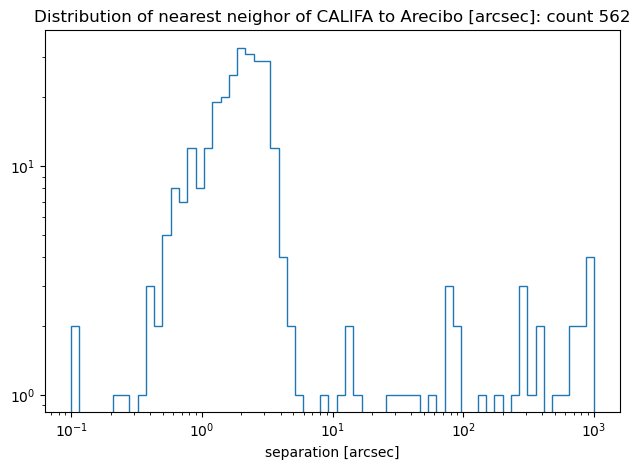

In [37]:
plt.hist(sep.arcsec, histtype="step", bins=np.logspace(-1, 3.0, 64))
plt.xlabel("separation [arcsec]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Distribution of nearest neighor of CALIFA to Arecibo [arcsec]: count {len(sep)}")
plt.tight_layout()

In [38]:
idx, sep, _ = t5n_c.match_to_catalog_sky(a100_c)

(sep < 10 * u.arcsec).sum(), len(t5n_c)

(np.int64(15), 361)

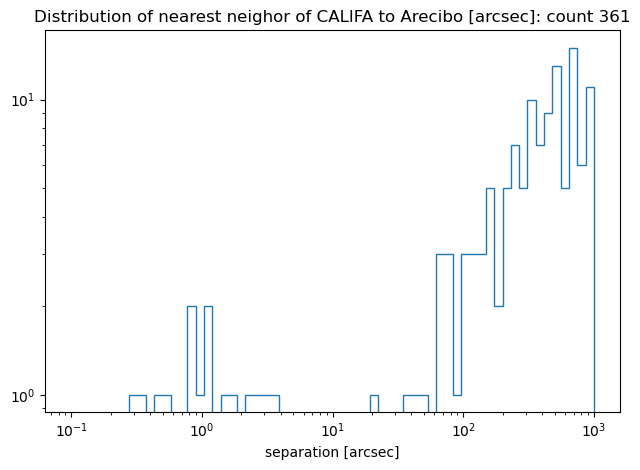

In [39]:
plt.hist(sep.arcsec, histtype="step", bins=np.logspace(-1, 3.0, 64))
plt.xlabel("separation [arcsec]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Distribution of nearest neighor of CALIFA to Arecibo [arcsec]: count {len(sep)}")
plt.tight_layout()

In [40]:
idx, sep, _ = t31_c.match_to_catalog_sky(a100_c)

(sep < 10 * u.arcsec).sum(), len(t31)

(np.int64(62), 159)

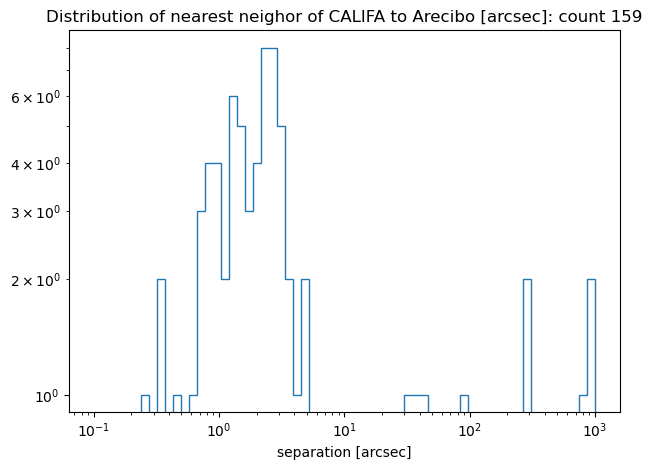

In [41]:
plt.hist(sep.arcsec, histtype="step", bins=np.logspace(-1, 3.0, 64))
plt.xlabel("separation [arcsec]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Distribution of nearest neighor of CALIFA to Arecibo [arcsec]: count {len(sep)}")
plt.tight_layout()

arguable all less than 10" are spot on. That's 62 out of the 159, not bad.

There are 23/159 galaxies in CALIFA_HI that seem to overlap with Arecibo, if HI location used. But 62 if the OC location!!

In [42]:
a100_near = a100[idx]
print(len(a100_near))
a100_near["sep"] = sep.arcsec

159


In [43]:
#t31.keys()   # Name, SigInt, ledaHIflux

In [44]:
# add more columns.... I didn't know how to do the join here
a100_near["Name2"] = t31["Name"]
a100_near["SigInt"] = t31["SigInt"]

Cut the 159 down to 62

In [45]:
see = ["AGCNr","Name","Name2","RAdeg_OC","DECdeg_OC","HIflux", "SigInt", "sep"]
idx2 = a100_near["sep"] < 10
a100_near2 = a100_near[idx2]
a100_near2[see]

AGCNr,Name,Name2,RAdeg_OC,DECdeg_OC,HIflux,SigInt,sep
,,,,,,Jy km / s,
int64,str8,str23,float64,float64,float64,float32,float64
4096,I.480...,IC0480,118.84666,26.74333,5.36,4.368420124053955,2.274518219116862
5064,I.540...,IC0540,142.5425,7.90194,1.26,1.294010043144226,3.175199107272204
8766,I.944...,IC0944,207.87875,14.09167,3.46,2.505880117416382,1.6360544796607173
10113,I1151...,IC1151,239.63499,17.44111,10.89,7.9736199378967285,1.5298100189078176
10242,I1199...,IC1199,242.6429,10.03972,3.38,0.3363969922065735,2.591544693362521
5059,I2487...,IC2487,142.53708,20.09028,9.19,7.750919818878174,4.738887177102049
12909,I5376...,IC5376,0.3325,34.52555,7.09,5.550469875335693,0.7916474574034045
810,N.444...,NGC0444,18.95708,31.08028,5.42,5.231369972229004,1.1497463771818364


Text(0, 0.5, 'GBT++')

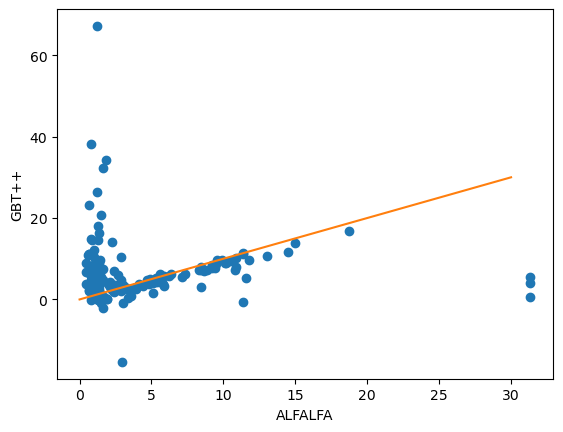

In [46]:
plt.plot(a100_near["HIflux"], a100_near["SigInt"],"o")
plt.plot([0,30],[0,30])
plt.xlabel("ALFALFA")
plt.ylabel("GBT++")

ok, quite a lot of weak arecibo data have good GBT fluxes.  But not the other way around.  Need to see spectra.

In [47]:
# names of all the califa galaxies where hi was detected - or so they claim
t6 = QTable.read('hiedge_all.csv')
